# Mall / Store Customer Clustering

In [1]:
import joblib
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from yellowbrick.cluster import KElbowVisualizer

In [4]:
df = pd.read_csv("Different_stores_data.csv")

In [5]:
df["Total_Purchase_Amount"] = df["quantity"] * df["selling_price_per_unit"]

In [6]:
customer_df = (
    df.groupby("customer_id")
    .agg({"age": "mean", "Total_Purchase_Amount": "sum", "quantity": "sum"})
    .reset_index()
)

In [7]:
customer_df = customer_df.dropna()

In [8]:
x = customer_df[["age", "Total_Purchase_Amount", "quantity"]]

In [9]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

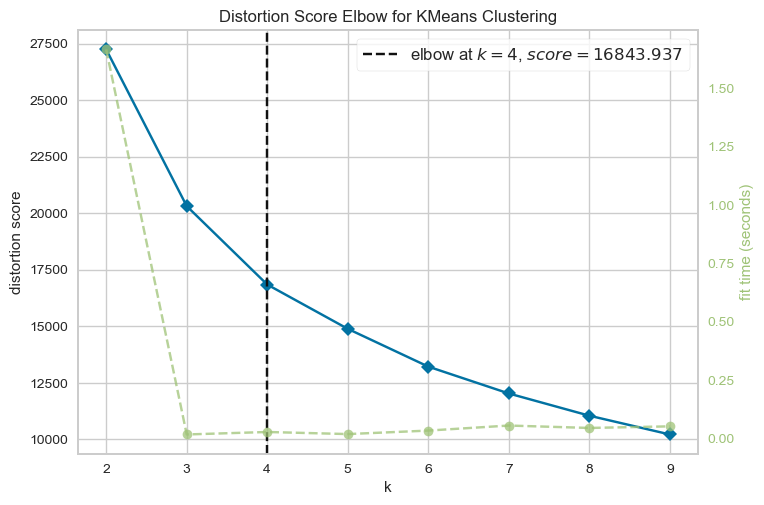

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [10]:
model = KMeans(random_state=42)
vis = KElbowVisualizer(model, k=(2, 10))
vis.fit(x_scaled)
vis.show()

In [12]:
optimal_k = vis.elbow_value_ if vis.elbow_value_ is not None else 4

In [14]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(x_scaled)
customer_df["Cluster"] = clusters

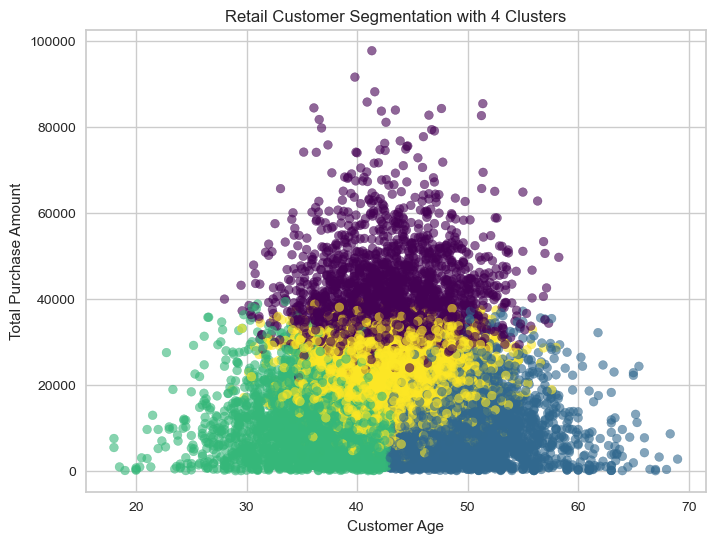

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(
    customer_df["age"],
    customer_df["Total_Purchase_Amount"],
    c=customer_df["Cluster"],
    cmap="viridis",
    alpha=0.6,
    s=40,
)
plt.title(f"Retail Customer Segmentation with {optimal_k} Clusters")
plt.xlabel("Customer Age")
plt.ylabel("Total Purchase Amount")
plt.show()

In [16]:
joblib.dump(kmeans, "real_data_clustering_model.pkl")

['real_data_clustering_model.pkl']